In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:

df = pd.read_csv('airline_passengers.csv', index_col='Month', parse_dates=True)

In [ ]:
df.head(50)

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
1949-06-01,135
1949-07-01,148
1949-08-01,148
1949-09-01,136


<Axes: xlabel='Month'>

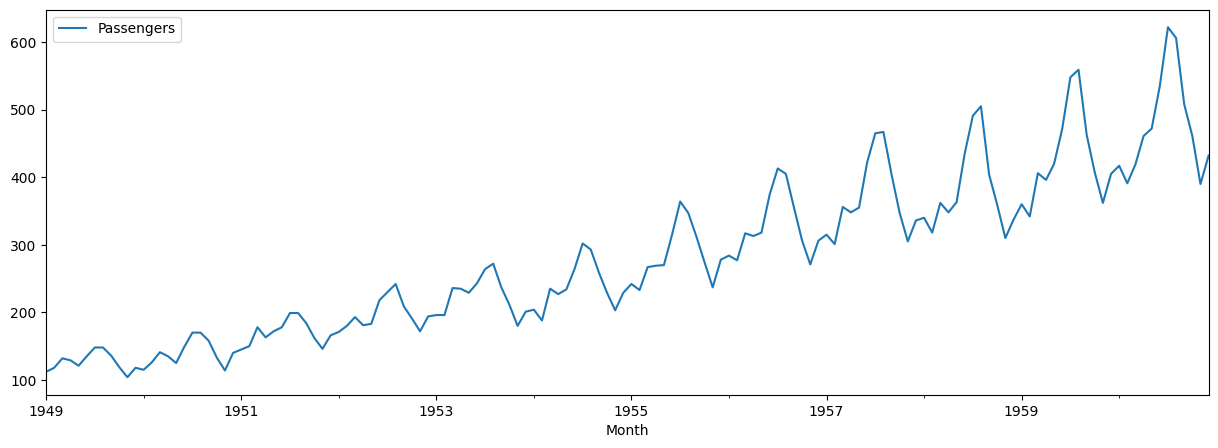

In [ ]:

df.plot(figsize=(15, 5))

In [ ]:

df['1stdiff'] = df['Passengers'].diff()

<Axes: xlabel='Month'>

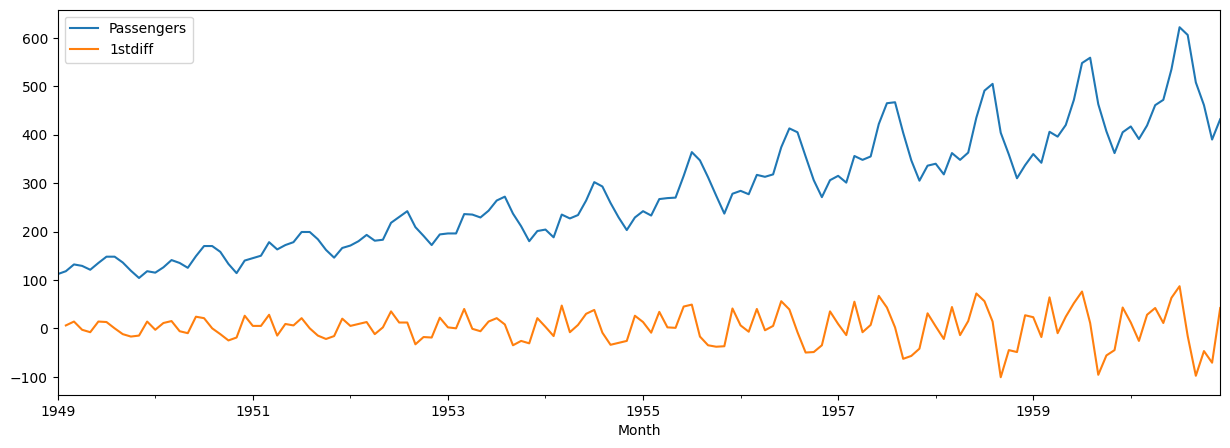

In [ ]:
df.plot(figsize=(15, 5))

<Axes: xlabel='Month'>

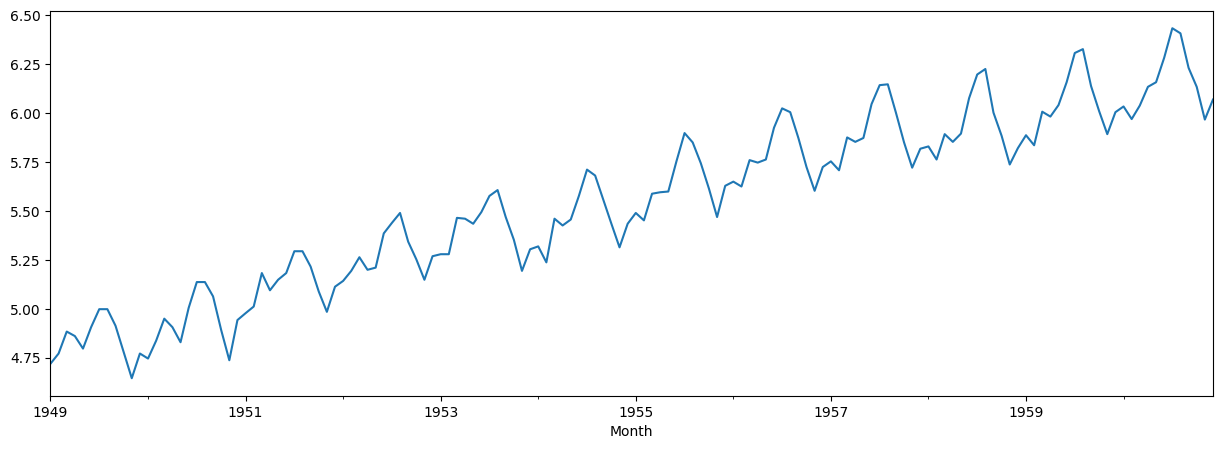

In [ ]:
df['LogPassengers'] = np.log(df['Passengers'])
df['LogPassengers'].plot(figsize=(15, 5))

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
Ntest = 12
train = df.iloc[:-Ntest]
test = df.iloc[-Ntest:]

train_idx = df.index <= train.index[-1]
test_idx = df.index > train.index[-1]

In [ ]:
## ARIMA
## AR(p): Model autoregresiv de ordinul p
## y = b + w1 * y-1 + w2 * y-2 + ... + wp * y-p
## MA(q): Moving average de ordinul q
## yt = c + et + o1 * et-1 + ... + oq * et-q
# et-q = valoare prezisa - valoare actuala la pasul q, et-> cunoscut in antrenare
## I(i) - Diferentiative part
def plot_fit_and_forecast_int(result, d, col='Passengers'):
  fig, ax = plt.subplots(figsize=(15,5))
  ax.plot(df[col], label="data")

  train_pred = result.predict(start=train.index[d], end=train.index[-1])
  ax.plot(train.index[d:], train_pred, color='green', label='fitted')

  prediction_result = result.get_forecast(Ntest)
  conf_int = prediction_result.conf_int()
  lower, upper = conf_int[f'lower {col}'], conf_int[f'upper {col}']
  forecast = prediction_result.predicted_mean
  ax.plot(test.index, forecast, label='forecast')
  ax.fill_between(test.index, lower, upper, color='red', alpha=0.3)

  ax.legend()


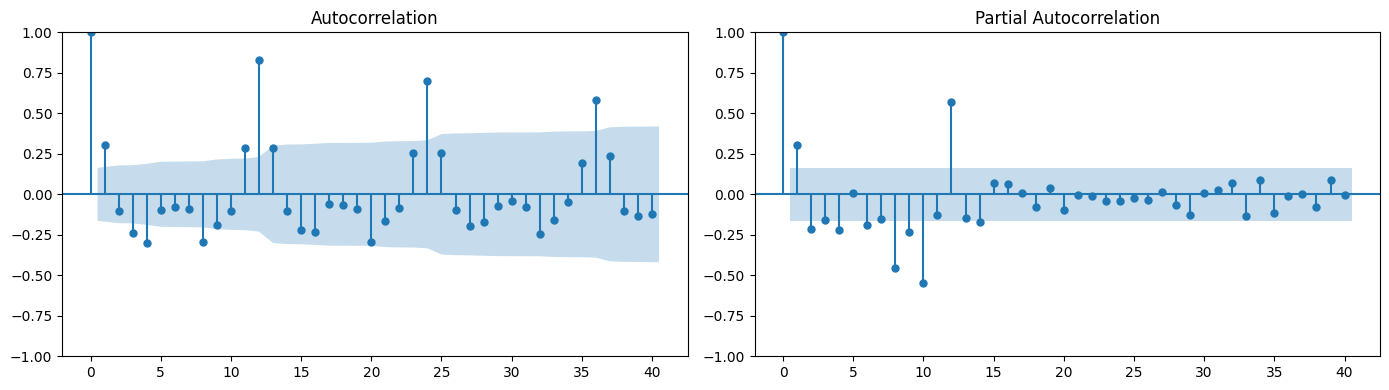

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

df['diff1'] = df['Passengers'].diff()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(df['diff1'].dropna(), lags=40, ax=axes[0])
plot_pacf(df['diff1'].dropna(), lags=40, ax=axes[1], method='ywm')
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. 

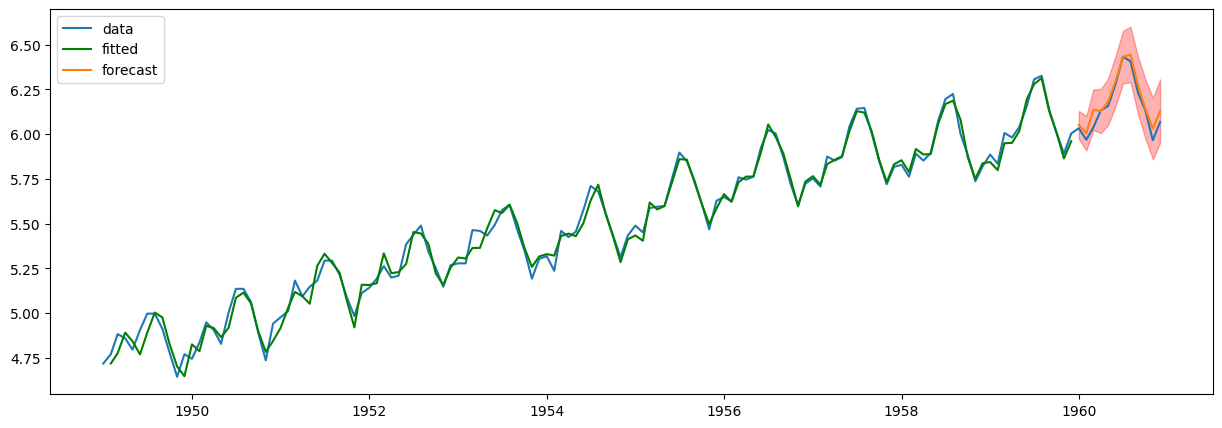

In [ ]:

arima = ARIMA(train['LogPassengers'], order=(12,1,4))
arima_result_log1212 = arima.fit()
plot_fit_and_forecast_int(arima_result_log1212, 1, col='LogPassengers')


In [ ]:
from sklearn.metrics import r2_score
prediction_result = arima_result_log1212.get_forecast(Ntest).predicted_mean
r2_score(test['Passengers'], np.exp(prediction_result))

0.9273715801506855

In [ ]:
df

,Passengers,1stdiff,LogPassengers,diff1,diff_both
Month,,,,,
1949-01-01,112,NaN,4.718499,NaN,NaN
1949-02-01,118,6.0,4.770685,6.0,NaN
1949-03-01,132,14.0,4.882802,14.0,NaN
1949-04-01,129,-3.0,4.859812,-3.0,NaN
1949-05-01,121,-8.0,4.795791,-8.0,NaN
...,...,...,...,...,...
1960-08-01,606,-16.0,6.406880,-16.0,-27.0
1960-09-01,508,-98.0,6.230481,-98.0,-2.0
1960-10-01,461,-47.0,6.133398,-47.0,9.0


In [ ]:
## Prophet
## Model aditiv: y(t) = g(t) + s(t) + h(t) + et
## g(t) - trend, s(t) - sezonalitate, h(t) - sarbatori
## Prophet cere coloanele ds (data) si y (valoarea)
from prophet import Prophet

prophet_train = train.reset_index().rename(columns={'Month': 'ds', 'Passengers': 'y'})
prophet_test = test.reset_index().rename(columns={'Month': 'ds', 'Passengers': 'y'})

# seasonality_mode multiplicativ: amplitudinea sezonului creste cu trendul
prophet = Prophet(seasonality_mode='multiplicative', yearly_seasonality=True, changepoint_prior_scale=0.02)
prophet_result = prophet.fit(prophet_train)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


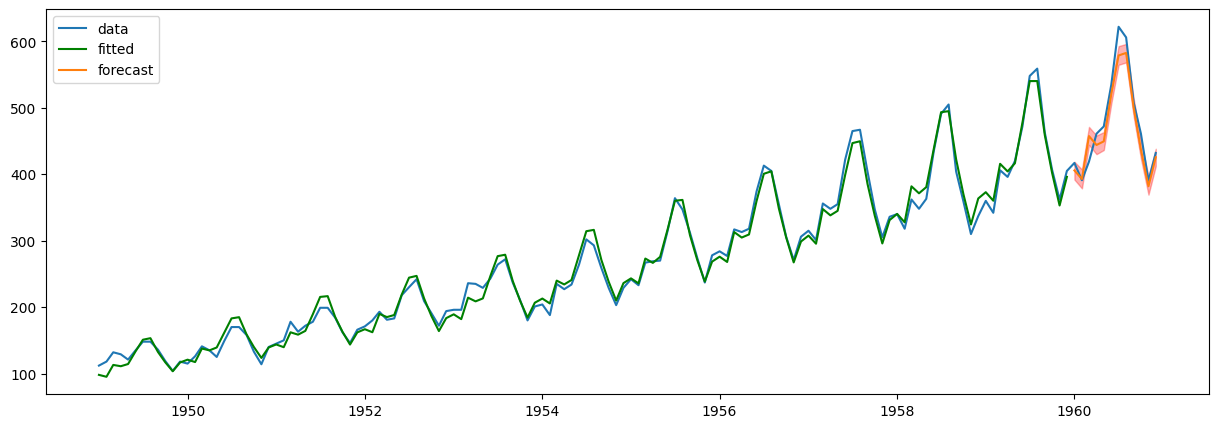

In [ ]:
def plot_prophet_fit_and_forecast(model, col='Passengers'):
  fig, ax = plt.subplots(figsize=(15,5))
  ax.plot(df[col], label="data")

  future = model.make_future_dataframe(periods=Ntest, freq='MS')
  fc = model.predict(future)

  train_pred = fc['yhat'].iloc[:-Ntest]
  ax.plot(train.index, train_pred, color='green', label='fitted')

  forecast = fc['yhat'].iloc[-Ntest:]
  lower, upper = fc['yhat_lower'].iloc[-Ntest:], fc['yhat_upper'].iloc[-Ntest:]
  ax.plot(test.index, forecast.values, label='forecast')
  ax.fill_between(test.index, lower.values, upper.values, color='red', alpha=0.3)

  ax.legend()
  return fc

fc = plot_prophet_fit_and_forecast(prophet_result)

In [ ]:
from sklearn.metrics import r2_score
prophet_forecast = fc['yhat'].iloc[-Ntest:]
r2_score(test['Passengers'], prophet_forecast)

0.9134651672765072